In [1]:
import pandas as pd
import os
from dotenv import load_dotenv
from HasHashtagAnalyser import HasHashtagAnalyser

load_dotenv()

DATA_DIR = os.getenv('DATA_DIR')
FACEBOOK_FILENAME = os.getenv('FB_FILENAME')
INSTAGRAM_FILENAME = os.getenv('IG_FILENAME')

facebook_loc = f"{DATA_DIR}/{FACEBOOK_FILENAME}"

#instagram_df = pd.read_csv(f"{DATA_DIR}/{INSTAGRAM_FILENAME}"),
facebook_df = pd.read_csv(facebook_loc).copy()

analyser = HasHashtagAnalyser(facebook_loc)
analyser.run_mann_whitney()

Photos: p=0.9974, HasHashtag median=0.017, ~HasHashtag median=0.014
Videos: p=0.0000, HasHashtag median=0.043, ~HasHashtag median=0.012


In [ ]:
# Clean data 
# Keep only relevant columns

In [40]:
# Make a text column where for Facebook videos title -> text, and Facebook photos description -> text.
import numpy as np
import re

facebook_df['Text'] = np.where(
    facebook_df['Post type'] == 'Videos',
    facebook_df['Description'],
    facebook_df['Title']
)

# Set all missing text to ""
facebook_df['Text'] = facebook_df['Text'].fillna("")

# Now let's include has a hashtag
# ( |\A)#(\w|\d)+( |$)
HASHTAG_REGEX = r"(?<!\S)#\w+(?!\S)"
facebook_df['HashtagCount'] = [len(re.findall(HASHTAG_REGEX, x)) for x in facebook_df['Text']]

facebook_df['HasHashtag'] = [x > 0 for x in facebook_df['HashtagCount']]


<Axes: title={'center': 'Percentage of Facebook Photos with N hashtags'}, xlabel='HashtagCount'>

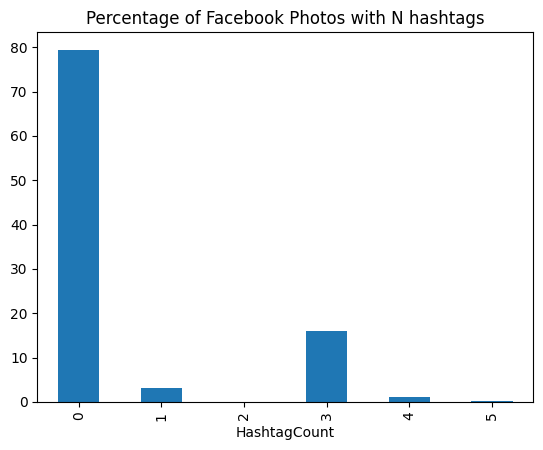

In [34]:

# Get pct bar chart of number of hashtags on photos
facebook_photos_hashtags = facebook_df[facebook_df['Post type'] == 'Photos']['HashtagCount'].value_counts().sort_index()
facebook_videos_hashtags = facebook_df[facebook_df['Post type'] == 'Videos']['HashtagCount'].value_counts().sort_index()


facebook_photos_hashtags /= facebook_photos_hashtags.sum()/100
facebook_videos_hashtags /= facebook_videos_hashtags.sum()/100

# Account for no posts existing with N hashtags
facebook_photos_hashtags = facebook_photos_hashtags.reindex(range(0, facebook_photos_hashtags.index.max() + 1), fill_value=0)
facebook_videos_hashtags = facebook_videos_hashtags.reindex(range(0, facebook_videos_hashtags.index.max() + 1), fill_value=0)

facebook_photos_hashtags.plot(kind='bar', title='Percentage of Facebook Photos with N hashtags')


<Axes: title={'center': 'Percentage of Facebook Videos with N hashtags'}, xlabel='HashtagCount'>

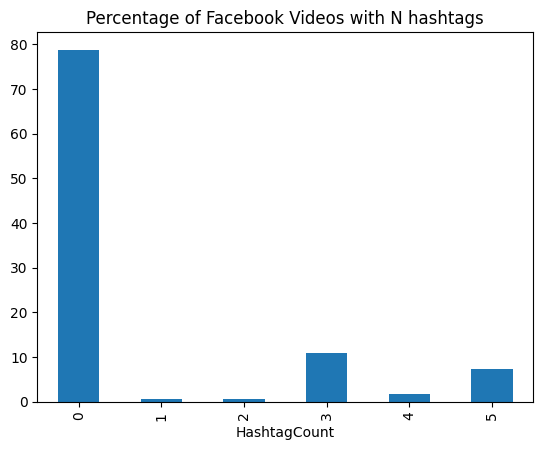

In [32]:

facebook_videos_hashtags.plot(kind='bar', title='Percentage of Facebook Videos with N hashtags')

<h3>Now we're going to split our posts into with hashtag and without and then test to see if having a hashtag leads to more engagement</h3>

In [47]:
# Extract only relevant columns
# - HasHashtag
# - Engagement Metrics [Views, Reach, Shares, Reactions, Comments]

engagement_column_names = ['Views', 'Reach', 'Shares', 'Reactions', 'Comments']
mask = ['HasHashtag']
mask.extend(engagement_column_names)

facebook_photos_df = facebook_df[facebook_df['Post type'] == 'Photos'].copy()
facebook_photos_df = facebook_photos_df[mask]

facebook_videos_df = facebook_df[facebook_df['Post type'] == 'Videos'].copy()
facebook_videos_df = facebook_videos_df[mask]

# Apply the test
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import mannwhitneyu

for df, name in [(facebook_photos_df, 'Photos'), (facebook_videos_df, 'Videos')]:
    # build composite engagement score
    scaled = MinMaxScaler().fit_transform(df[engagement_column_names])
    df['engagement_score'] = scaled.mean(axis=1)
    
    # split groups
    hashtag = df[df['HasHashtag']]['engagement_score']
    no_hashtag = df[~df['HasHashtag']]['engagement_score']
    
    # test
    stat, p = mannwhitneyu(hashtag, no_hashtag)
    print(f"{name}: p={p:.4f}, hashtag median={hashtag.median():.3f}, no hashtag median={no_hashtag.median():.3f}")

Photos: p=0.9974, hashtag median=0.017, no hashtag median=0.014
Videos: p=0.0000, hashtag median=0.043, no hashtag median=0.012
